In [1]:
import zipfile
import pandas as pd
import os

# Step 1 – Extract the zip file
zip_path = "walmart_sales_data.zip"
extract_folder = "walmart_data"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("✅ Files extracted to:", extract_folder)

# Step 2 – List extracted files
os.listdir(extract_folder)



✅ Files extracted to: walmart_data


['features.csv', 'stores.csv', 'test.csv', 'train.csv']

In [2]:
# Load datasets
train_df = pd.read_csv("walmart_data/train.csv")
features_df = pd.read_csv("walmart_data/features.csv")
stores_df = pd.read_csv("walmart_data/stores.csv")

# Display basic info
print("✅ Datasets Loaded Successfully!\n")

print("Train Shape:", train_df.shape)
print("Features Shape:", features_df.shape)
print("Stores Shape:", stores_df.shape)

# Preview top rows
print("\n🧾 Train Data:")
display(train_df.head())

print("\n🏪 Stores Data:")
display(stores_df.head())

print("\n📊 Features Data:")
display(features_df.head())


✅ Datasets Loaded Successfully!

Train Shape: (421570, 5)
Features Shape: (8190, 12)
Stores Shape: (45, 3)

🧾 Train Data:


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False



🏪 Stores Data:


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875



📊 Features Data:


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [3]:
  # Merge all dataframes into one master dataset
merged_df = train_df.merge(stores_df, on='Store', how='left')
merged_df = merged_df.merge(features_df, on=['Store', 'Date', 'IsHoliday'], how='left')

print("✅ Merged Data Shape:", merged_df.shape)

# Quick look at merged data
display(merged_df.head())

# Check for missing values
missing = merged_df.isnull().sum().sort_values(ascending=False)
print("\n🔍 Missing Values (Top 10):")
print(missing.head(10))


✅ Merged Data Shape: (421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106



🔍 Missing Values (Top 10):
MarkDown2      310322
MarkDown4      286603
MarkDown3      284479
MarkDown1      270889
MarkDown5      270138
Store               0
Date                0
Dept                0
Temperature         0
Size                0
dtype: int64


C:\Users\vamsi\AppData\Local\Temp\ipykernel_3968\3077684582.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_by_year, x='Year', y='Weekly_Sales', palette='coolwarm')
C:\ai-bi-assistant\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129517 (\N{COMPASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


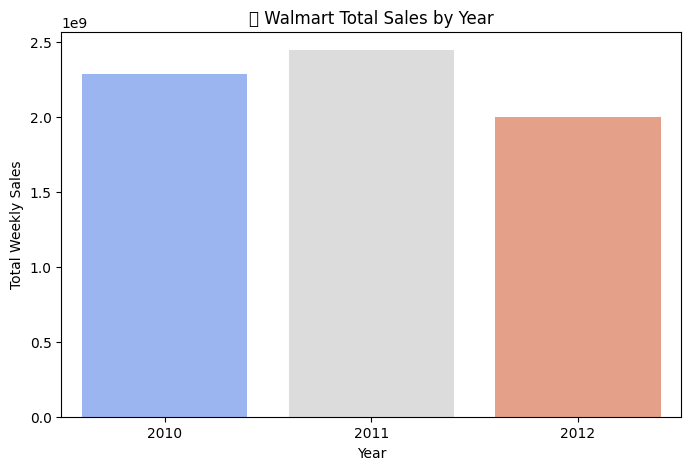

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Date' column to datetime
merged_df['Date'] = pd.to_datetime(merged_df['Date'])

# Create Year and Month columns
merged_df['Year'] = merged_df['Date'].dt.year
merged_df['Month'] = merged_df['Date'].dt.month

# Total sales by year
sales_by_year = merged_df.groupby('Year')['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=sales_by_year, x='Year', y='Weekly_Sales', palette='coolwarm')
plt.title('🧭 Walmart Total Sales by Year')
plt.ylabel('Total Weekly Sales')
plt.xlabel('Year')
plt.show()


In [5]:
!pip install seaborn matplotlib


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\vamsi\AppData\Local\Temp\ipykernel_3968\1720287123.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=store_sales, x='Type', y='Weekly_Sales', palette='mako')
C:\ai-bi-assistant\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127980 (\N{DEPARTMENT STORE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


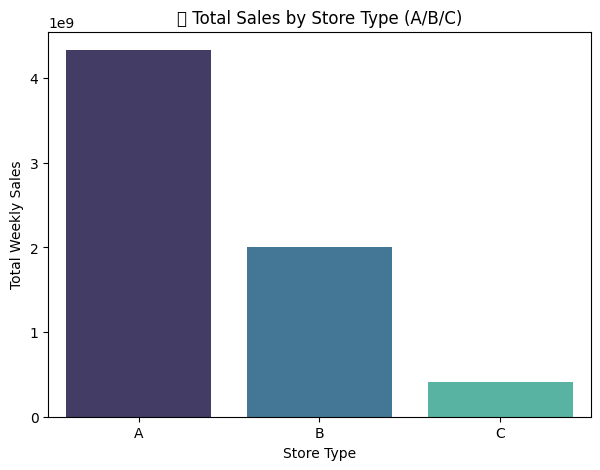

,Type,Weekly_Sales
0,A,4.331015e+09
1,B,2.000701e+09
2,C,4.055035e+08


In [7]:
# Total sales by store type
store_sales = merged_df.groupby('Type')['Weekly_Sales'].sum().reset_index().sort_values('Weekly_Sales', ascending=False)

plt.figure(figsize=(7,5))
sns.barplot(data=store_sales, x='Type', y='Weekly_Sales', palette='mako')
plt.title('🏬 Total Sales by Store Type (A/B/C)')
plt.ylabel('Total Weekly Sales')
plt.xlabel('Store Type')
plt.show()

store_sales


C:\Users\vamsi\AppData\Local\Temp\ipykernel_3968\1764301880.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=holiday_sales, x='IsHoliday', y='Weekly_Sales', palette='flare')
C:\ai-bi-assistant\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


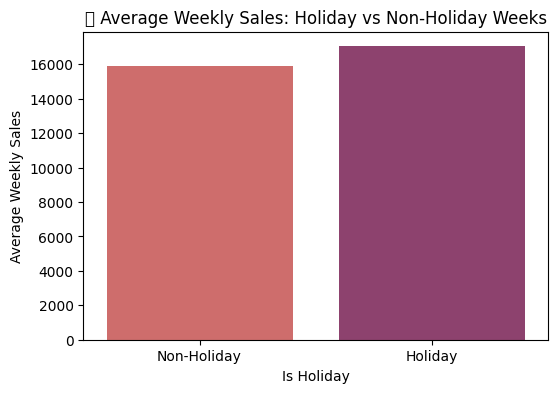

,IsHoliday,Weekly_Sales
0,False,15901.445069
1,True,17035.823187


In [8]:
# Average sales on holidays vs non-holidays
holiday_sales = merged_df.groupby('IsHoliday')['Weekly_Sales'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=holiday_sales, x='IsHoliday', y='Weekly_Sales', palette='flare')
plt.title('🎉 Average Weekly Sales: Holiday vs Non-Holiday Weeks')
plt.ylabel('Average Weekly Sales')
plt.xlabel('Is Holiday')
plt.xticks([0, 1], ['Non-Holiday', 'Holiday'])
plt.show()

holiday_sales


C:\ai-bi-assistant\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


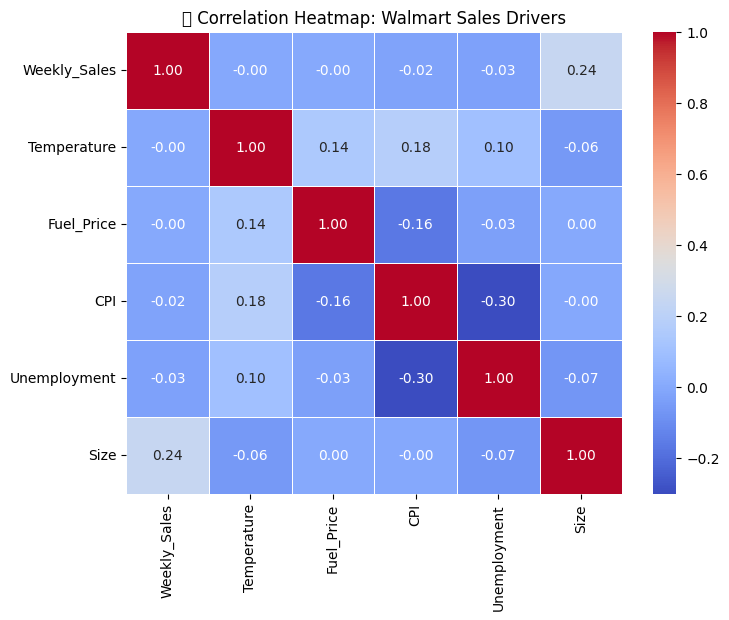

In [9]:
# Select numeric columns for correlation
corr_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size']
corr = merged_df[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('🔥 Correlation Heatmap: Walmart Sales Drivers')
plt.show()


In [10]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Model R² Score: 0.933
Root Mean Squared Error: 5,916.39


C:\Users\vamsi\AppData\Local\Temp\ipykernel_3968\2430187654.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='crest')


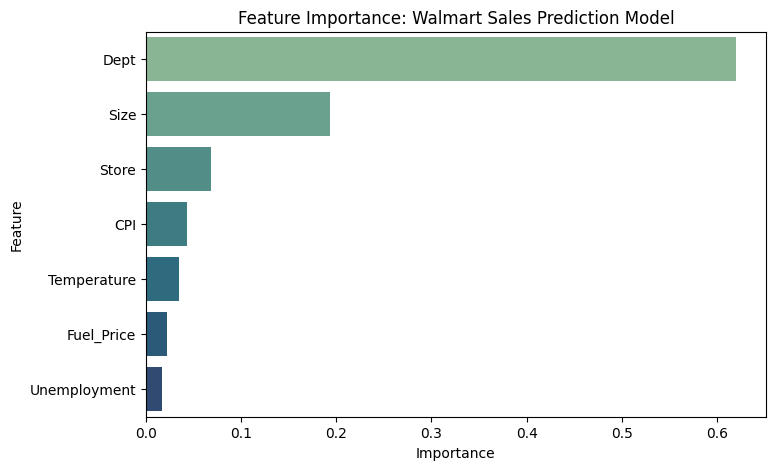

,Feature,Importance
1,Dept,0.620458
6,Size,0.193697
0,Store,0.067988
4,CPI,0.043524
2,Temperature,0.034904
3,Fuel_Price,0.022199
5,Unemployment,0.017230


In [13]:
# Step 9: Machine Learning Model for Walmart Weekly Sales

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Select features and target
features = ['Store', 'Dept', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size']
X = merged_df[features]
y = merged_df['Weekly_Sales']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate model performance
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Model R² Score: {r2:.3f}")
print(f"Root Mean Squared Error: {rmse:,.2f}")

# Feature importance visualization
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='crest')
plt.title('Feature Importance: Walmart Sales Prediction Model')
plt.show()

feature_importance

In [14]:
# Display model performance results and feature importance
print(f"Model R² Score: {r2:.3f}")
print(f"Root Mean Squared Error: {rmse:,.2f}")

# Display feature importance table
display(feature_importance)


Model R² Score: 0.933
Root Mean Squared Error: 5,916.39


,Feature,Importance
1,Dept,0.620458
6,Size,0.193697
0,Store,0.067988
4,CPI,0.043524
2,Temperature,0.034904
3,Fuel_Price,0.022199
5,Unemployment,0.017230
